In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_map(T, i=0, save_path=None):
    """
    Визуализация {i}-ой карты с начальной и конечной точками, а также результатом Дейкстры с прозрачными областями вне карты.

    Параметры:
        T (np.ndarray): Тензор данных размером (N, 64, 64, 4).
        i (int): Индекс карты для отображения.
        save_path (str): Путь для сохранения изображения (если указан).
    """
    B = T[..., 1]
    C = T[..., 2]
    D = T[..., 3]

    # Копируем массив расстояний и заменяем нули на NaN для прозрачных областей
    distances = np.copy(C[i])
    distances[distances == 0] = np.nan

    # Создаем цветовую карту с прозрачным фоном
    cmap = plt.cm.viridis
    cmap.set_bad(color=(0, 0, 0, 0))  # Прозрачный цвет для NaN

    plt.figure(figsize=(4, 4), dpi=150)
    plt.title(f"Map {i + 1}: Landscape with Points")

    # Визуализация карты с прозрачным фоном для областей вне карты
    img = plt.imshow(distances, cmap=cmap, vmin=0, vmax=np.nanmax(distances))

    # Наносим начальную и конечную точки
    start_point = np.argwhere(D[i] == 1)
    end_point = np.argwhere(B[i] == 1)

    if len(start_point) > 0:
        plt.scatter(start_point[0, 1], start_point[0, 0], color='blue', label='Start', s=100)
    if len(end_point) > 0:
        plt.scatter(end_point[0, 1], end_point[0, 0], color='red', label='End', s=100)

    plt.legend()
    plt.colorbar(img, label='Distance to End Point')

    # Сохраняем изображение, если указан путь
    if save_path:
        plt.savefig(save_path, transparent=True, bbox_inches='tight')

    plt.show()

def plot_multiple_maps(T, num_maps=5, save_dir="maps"):
    """
    Отображение нескольких карт с сохранением изображений.

    Параметры:
        T (np.ndarray): Тензор данных размером (N, 64, 64, 4).
        num_maps (int): Количество карт для отображения.
        save_dir (str): Директория для сохранения изображений.
    """
    import os

    # Создаем директорию для сохранения изображений, если её нет
    os.makedirs(save_dir, exist_ok=True)

    for i in range(min(num_maps, T.shape[0])):
        save_path = os.path.join(save_dir, f"map_{i + 1}.pdf")
        plot_map(T, i, save_path=save_path)

In [17]:
from ABCD.ABCD import generate_BCD
import importlib
import map_generators.pfu as pfu

In [18]:
importlib.reload(pfu) 

<module 'map_generators.pfu' from '/home/silvarum/TransPath_Adaptation/dataset_functions/map_generators/pfu/__init__.py'>

Mark start: 100%|██████████| 1/1 [00:00<00:00, 1053.32it/s]


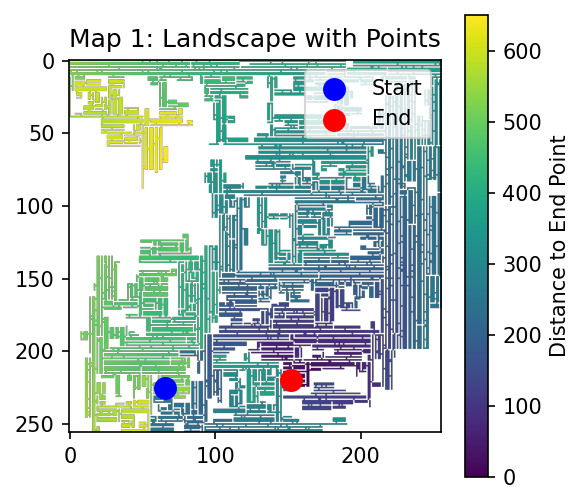

In [47]:
plot_map(generate_BCD(pfu.pfu["recursive_division"](256).reshape(1, 256, 256)))

Dijkstra calculation:   0%|          | 0/1 [00:00<?, ?it/s]

Mark start: 100%|██████████| 1/1 [00:00<00:00, 904.33it/s]


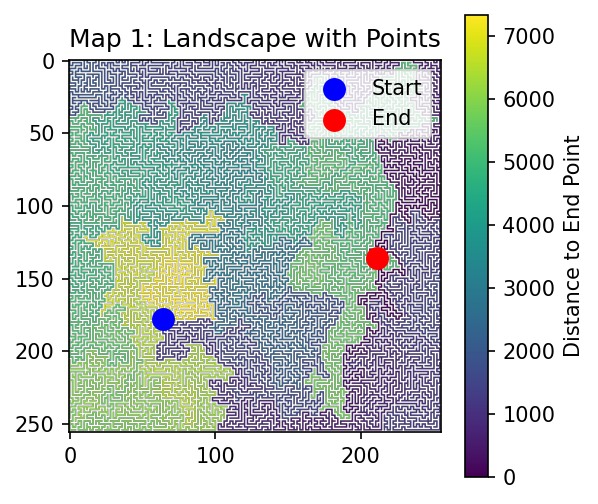

(512, 512)


Mark start: 100%|██████████| 1/1 [00:00<00:00, 1400.90it/s]


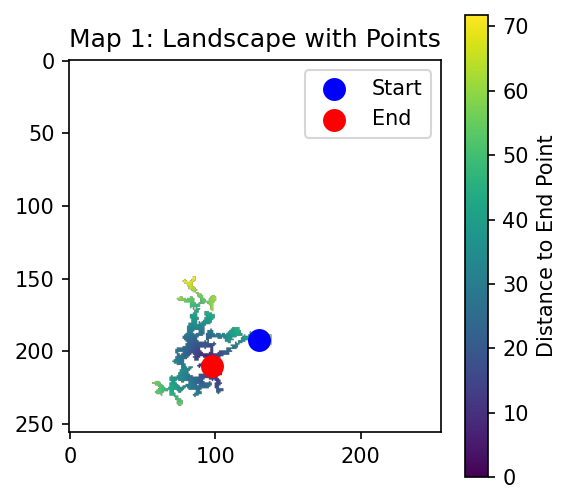

(512, 512)


Mark start: 100%|██████████| 1/1 [00:00<00:00, 934.35it/s]


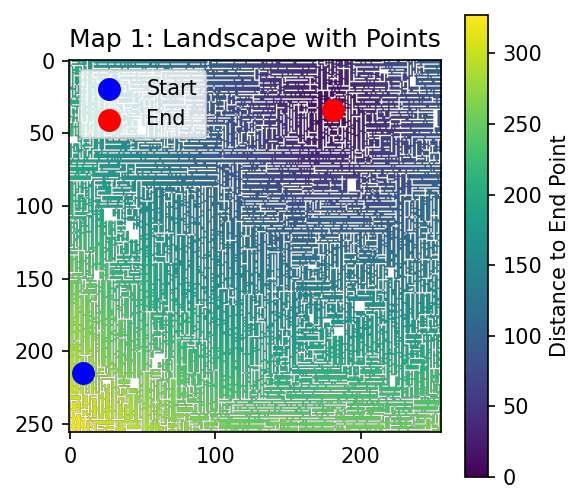

(512, 512)


Mark start: 100%|██████████| 1/1 [00:00<00:00, 568.95it/s]


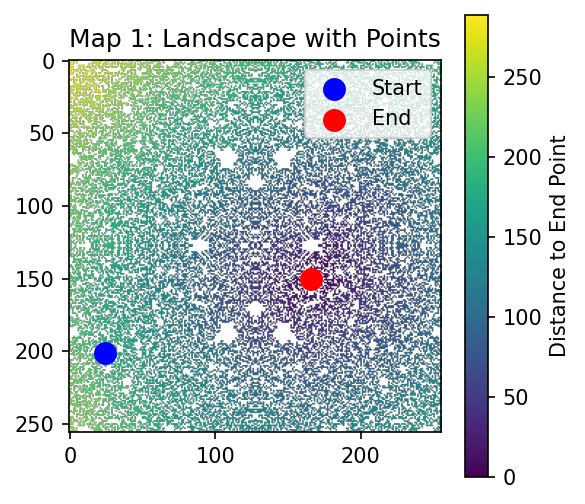

(512, 512)


Mark start: 100%|██████████| 1/1 [00:00<00:00, 1043.88it/s]


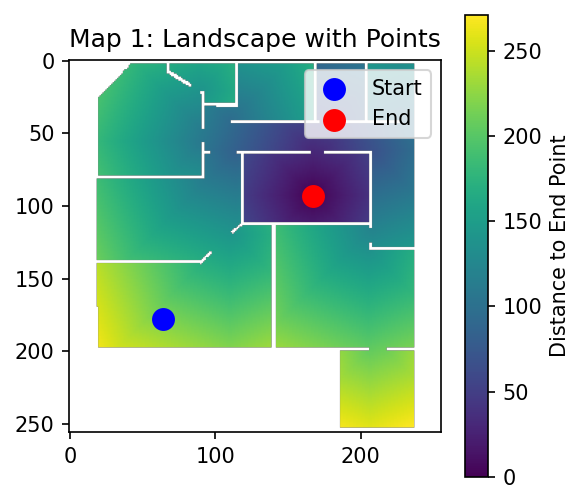

(512, 512)


Mark start: 100%|██████████| 1/1 [00:00<00:00, 947.22it/s]


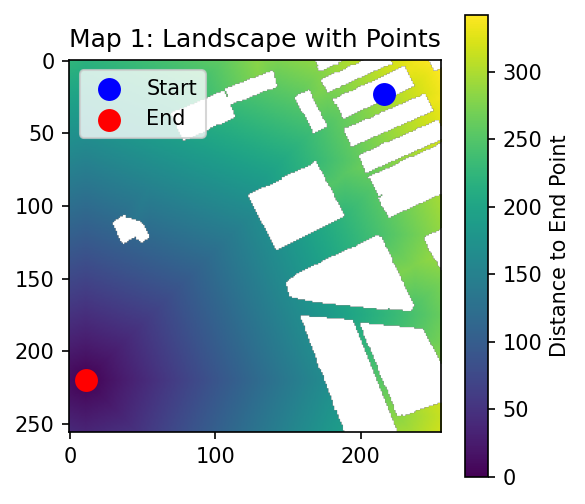

(512, 512)


Mark start: 100%|██████████| 1/1 [00:00<00:00, 1215.39it/s]


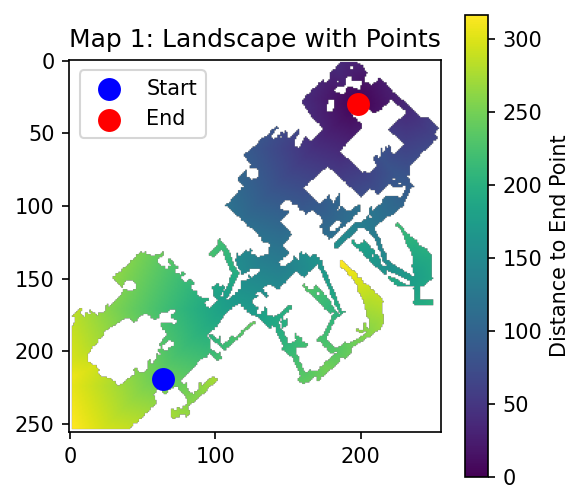

(512, 512)


Mark start: 100%|██████████| 1/1 [00:00<00:00, 998.41it/s]


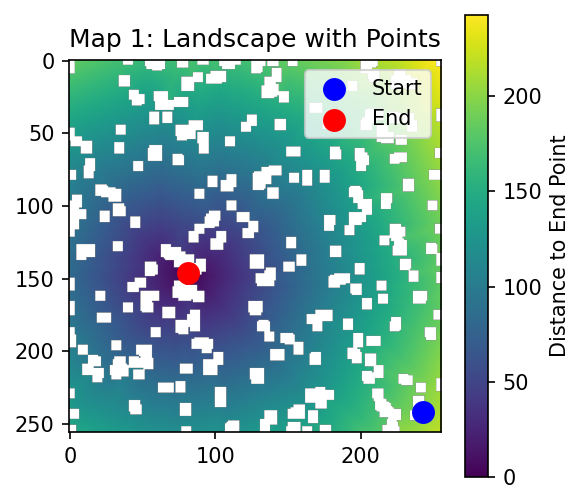

(512, 512)


ValueError: cannot reshape array of size 16384 into shape (1,256,256)

In [9]:
for key in pfu.pfu.keys():
        plot_map(generate_BCD(pfu.pfu[key](256).reshape(1, 256, 256)))
        print(pfu.pfu[key](512).shape)

Mark start: 100%|██████████| 1/1 [00:00<00:00, 1781.02it/s]


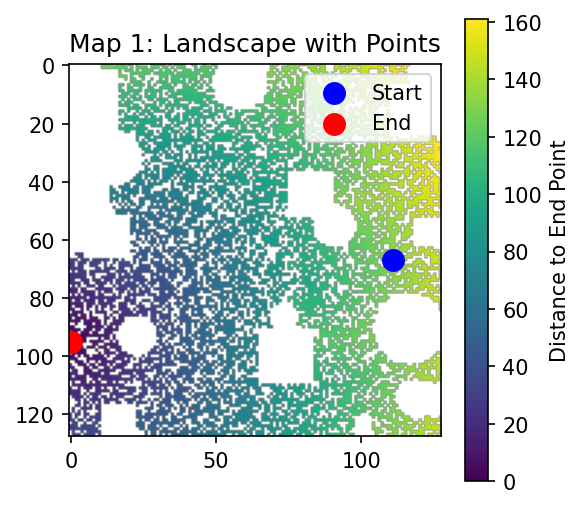

In [22]:
qr = generate_QRs()
figures = generate_figures()
# plot_map(generate_BCD(qr.reshape(1, 128, 128)))
# plot_map(generate_BCD(figures.reshape(1, 128, 128)))
res = qr.astype(bool) * figures.astype(bool)
plot_map(generate_BCD(res.reshape(1, 128, 128)))

Mark start: 100%|██████████| 1/1 [00:00<00:00, 1333.22it/s]


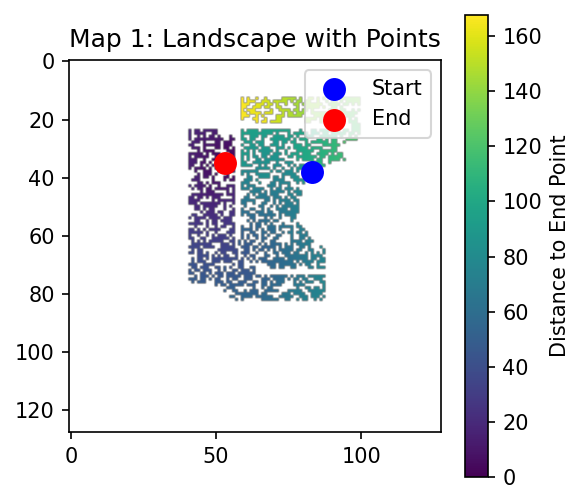

In [44]:
res = qr.astype(bool) * figures.astype(bool)
plot_map(generate_BCD(res.reshape(1, 128, 128)))

In [ ]:
plot_map(generate_BCD(figures.reshape(1, 128, 128)))

In [2]:
import numpy as np
beta_figures = np.load("/home/silvarum/TransPath_Adaptation/datasets/128/beta_figurs.npy")
print(beta_figures.shape)

(256000, 128, 128, 4)


In [3]:
un = np.load("/home/silvarum/TransPath_Adaptation/datasets/128/uniform_figures.npy")
print(un.shape)

(256000, 128, 128, 4)


In [48]:
path = "/home/silvarum/TransPath_Adaptation/datasets/64/figures/train/maps.npy"

In [3]:
import numpy as np
# from pathlib import Path

# paths = list(Path("/home/silvarum/TransPath_Adaptation/datasets").rglob("maps.npy"))
# print(paths)
# for p in paths:
p="/home/silvarum/TransPath_Adaptation/datasets/64/pfu/test/maps.npy"
arr = np.load(p)      # загрузить булев массив
print(arr)
np.save(p, ~arr)      # инвертировать (True↔False) и перезаписать


[[[[ True False  True ... False  True False]
   [ True False  True ... False  True False]
   [ True False  True ...  True  True False]
   ...
   [ True False False ... False  True False]
   [ True  True  True ...  True  True False]
   [False False False ... False False False]]]


 [[[ True  True  True ...  True  True False]
   [False False  True ... False False False]
   [ True False  True ...  True  True False]
   ...
   [False False False ... False  True False]
   [ True  True  True ...  True  True False]
   [False False False ... False False False]]]


 [[[ True  True  True ...  True  True False]
   [False False False ... False  True False]
   [ True  True  True ... False  True False]
   ...
   [ True False  True ... False  True False]
   [ True  True  True ...  True  True False]
   [False False False ... False False False]]]


 ...


 [[[ True  True  True ...  True  True  True]
   [ True  True  True ...  True  True  True]
   [ True  True  True ...  True  True  True]
   ...
   [ Tru

In [ ]:
import numpy as np
print(np.load("/home/silvarum/TransPath_Adaptation/datasets/128/betanoised_figures/train/maps.np"))